<a href="https://colab.research.google.com/github/UBM-ML/artificial-neural-network-team-gerald/blob/main/02_mlp_sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Varian 02 — MLP 1 Hidden Layer (Sigmoid)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/02_mlp_sigmoid.ipynb)

**Anggota yang mengerjakan:** _Anggota 2_

---

## 🏗️ Arsitektur
1 hidden layer berisi **16 neuron**, lalu output 3 neuron.

## ⚡ Fungsi Aktivasi
Hidden layer menggunakan **Sigmoid** (rumus: f(x) = 1 / (1 + e^-x)). Range output 0..1. Output layer tetap softmax.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [6]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-team-gerald.git' # <<< THIS NEEDS TO BE REPLACED WITH YOUR ACTUAL REPO URL
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 30 (delta 6), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (30/30), 23.92 KiB | 11.96 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', '02_mlp_sigmoid.ipynb', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


## 2. Import library

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [8]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [9]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='sigmoid'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 2s - 153ms/step - accuracy: 0.6458 - loss: 1.0707 - val_accuracy: 0.5833 - val_loss: 1.0763
Epoch 2/100
12/12 - 0s - 17ms/step - accuracy: 0.6875 - loss: 1.0321 - val_accuracy: 0.5833 - val_loss: 1.0450
Epoch 3/100
12/12 - 0s - 10ms/step - accuracy: 0.6875 - loss: 0.9963 - val_accuracy: 0.5833 - val_loss: 1.0150
Epoch 4/100
12/12 - 0s - 10ms/step - accuracy: 0.6875 - loss: 0.9623 - val_accuracy: 0.5833 - val_loss: 0.9865
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.6875 - loss: 0.9300 - val_accuracy: 0.5833 - val_loss: 0.9595
Epoch 6/100
12/12 - 0s - 9ms/step - accuracy: 0.6875 - loss: 0.8992 - val_accuracy: 0.5833 - val_loss: 0.9339
Epoch 7/100
12/12 - 0s - 10ms/step - accuracy: 0.6875 - loss: 0.8699 - val_accuracy: 0.5833 - val_loss: 0.9095
Epoch 8/100
12/12 - 0s - 9ms/step - accuracy: 0.7188 - loss: 0.8420 - val_accuracy: 0.5833 - val_loss: 0.8863
Epoch 9/100
12/12 - 0s - 12ms/step - accuracy: 0.7500 - loss: 0.8155 - val_accuracy: 0.6250 - val_loss: 0.8642
Epo

## 6. Visualisasi kurva training

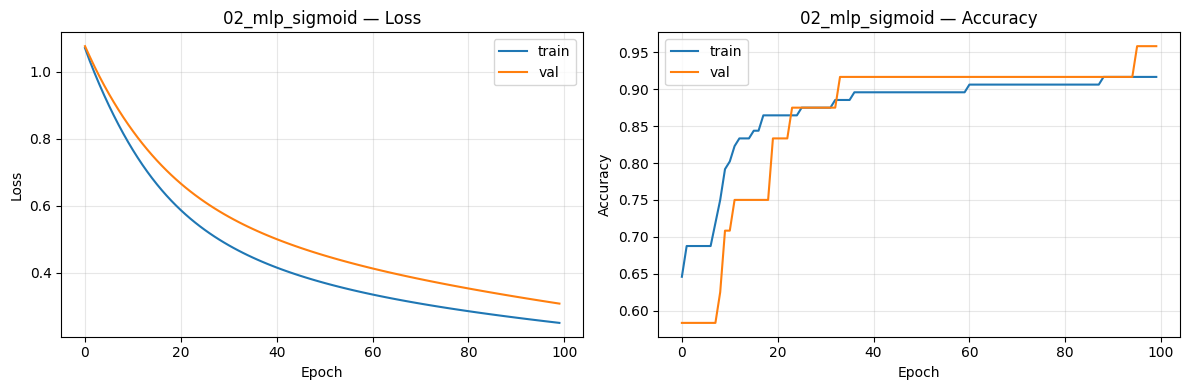

In [11]:
plot_training_curves(history, variant_name='02_mlp_sigmoid')


## 7. Evaluasi di test set

In [12]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='02_mlp_sigmoid')
save_history(history, variant_name='02_mlp_sigmoid')
summary



📊 02_mlp_sigmoid
   Test loss:     0.3025
   Test accuracy: 0.9333
   Jumlah parameter: 131
✅ History tersimpan di: results/02_mlp_sigmoid.csv


{'variant': '02_mlp_sigmoid',
 'test_loss': 0.3024522662162781,
 'test_accuracy': 0.9333333373069763,
 'n_params': 131}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Lihat kurva training-mu. Pada epoch berapa loss mulai stabil?
2. Apakah Sigmoid cocok untuk hidden layer? Coba kaitkan dengan fenomena 'vanishing gradient'.
3. Jika kamu menambah hidden layer kedua (lagi Sigmoid), apakah hasilnya membaik atau memburuk?


1. Berdasarkan log training, loss mulai terlihat stabil pada kisaran epoch 80 hingga 100.  Selisih penurunan di 20 epoch terakhir sudah sangat kecil (hanya sekitar 0.03), yang menandakan model sudah mulai konvergen dan stabil.
2. Sigmoid sebenarnya kurang ideal untuk hidden layer, apalagi jika modelnya makin dalam. Karena Vanishing Gradient, Fungsi Sigmoid memiliki turunan (gradient) maksimal hanya sebesar 0.25. Saat proses backpropagation, gradien ini akan dikalikan terus-menerus di setiap layer.
3. Hasilnya kemungkinan besar akan memburuk atau semakin lambat untuk konvergen. Dengan menambah layer Sigmoid lagi, masalah vanishing gradient yang dijelaskan sebelumnya akan semakin parah.